
<div align="center">
  <hr>
  <h1><strong>🧠 Repositorio RNA de Github</strong></h1>
 
  <hr>
</div>


El repositorio para aprendizaje de redes neuronales está disponible de forma  pública en https://github.com/RNA-UNIV/rna

El objetivo del repositorio es el de proveer funciones y clases con implementaciones básicas de algoritmos de redes neuronales, carga de datasets, carga de modelos y carga de ejemplos para pruebas y visualizciones.

Se instala directamente desde el repositorio mediante **pip install git+https://github.com/RNA-UNIV/rna.git**. Esta instalación descarga los archivos python para trabajar y prepara las estructuras de carpetas para realizar descargas de recursos (datasets, modelos, archivos, etc.) bajo demanda. Estos son los módulos dentro del paquete rna donde se encuentran definidos clases y funciones para diferentes tareas:
* **rna**: algoritmos de redes neuronales:
  - Perceptrón
  - Neurona lineal
  - Neurona general
  - Red neuronal multiclase.
* **rna.audio**: procesamiento de audio:
  - Recortar silencios
  - Ajuste de longitud
  - Audio a espectrograma Mel
  - Espectrograma a Imágen 
* **rna.callbacks**: callbacks para tensorflow:
  - Medidor de tiempo de entrenamiento
  - Visualizador de imagenes durante entrenamiento
* **rna.data**: carga de recursos:
  - Cargador de datasets
* **rna.images**: procesamiento de imagenes:
  - Panel de dibujo a mano alzada
  
## 🎯 Objetivo
Este notebook demuestra el uso del repositorio `rna` para:

- 📚 **Cargar datasets** (Iris, Titanic, Zoo, etc.)
- 📊 **Visualizar información** en formato JSON, árbol y tablas
- 🧠 **Implementar una red neuronal multiclase** con Softmax

## 📚 Contenido
- 🗃️ Instalación del Paquete
- 📥 Carga de datasets
- 🔍 Exploración de información
- 📊 Uso con NumPy y Pandas
- 🤖 Ejemplo de clasificación multiclase

## 🗃️ Instalación del Paquete

In [1]:
#pip install git+https://github.com/RNA-UNIV/rna.git --upgrade

# 📥 Carga de Recursos con DataLoader

La clase `DataLoader` permite administrar datasets, modelos y recursos descargados automáticamente.

## 🔧 Funciones principales
1. 📋 Listar datasets.
2. 🔍 Consultar información.
3. 📊 Cargar como NumPy.
4. 🐼 Cargar como DataFrame.

La clase **DataLoader** definida en **rna.data**, se encarga del manejo de todo lo asociado a la carga de datasets. Cada dataset se conoce con un nombre único. Algunas de las funciones que realiza son:
* **list_datasets**: listas los datasets disponibles en el repositorio git.
* **load_dataframe**: carga un dataset como dataframe.
* **load_array**: carga un dataset como arreglo numpy.
* **dataset_info**: ofrece información del dataset (nombre, descripción, autores, url de descarga, descripión breve de atributos, cantidad de ejemplos, etc.) en formato **json**.
* **dataset_info_display**: muestra en pantalla la información del dataset en formato amigable.
* **dataset_directory**: directorio local donde se encuentra el dataset. Útil para realizar algun tipo de procesamiento para archivos individuales como audios e imágenes.

En el repositorio Git de datasets, cada conjunto de datos cuenta con su propia carpeta, nombrada según el dataset. En su interior se encuentran el archivo de datos (en formato .csv o .zip), un documento Markdown con la documentación detallada y un archivo de metadatos (info.json). Estos archivos se descargan localmente bajo demanda, organizándose en una subcarpeta con el mismo nombre del dataset.

In [2]:
#import os, sys
#sys.path.insert(0, os.path.join(os.getcwd(),'..'))

from rna.data import DataLoader

# 🚀 Ejemplos de Uso

<div style="background-color: #e7f3fe; border-left: 6px solid #2196F3; padding: 12px; border-radius: 4px; margin: 10px 0;">
  <strong>💡 Recomendación</strong> <br>
   Ejecute las celdas secuencialmente para comprender el flujo completo de trabajo.
</div>

In [3]:
!pip install chardet
!pip install librosa


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


## 🔍 Información del Dataset **Fingers**
`dataset_info` retorna la información en formato **json** mientras que `dataset_info_display` muestra la información en formato mas legible, ej: arbol

In [44]:


# Usar método dataset_info para recuperar json con la información
DataLoader.dataset_info_display('fingers')

<IPython.core.display.JSON object>

## 📊 Carga del dataset **Fingers** como arreglo NumPy
Carga el dataset completo en memoria

In [16]:
(X, y, cls_names) = DataLoader.load_images('fingers_test', resize=(40,40))

print(X.shape)

Cargando fingers: 100%|█████████████████████████████████████████████████████| 21600/21600 [07:43<00:00, 46.57 archivo/s]
(21600, 40, 40, 1)


## 🐼 Muestra Imégenes de Ejemplo

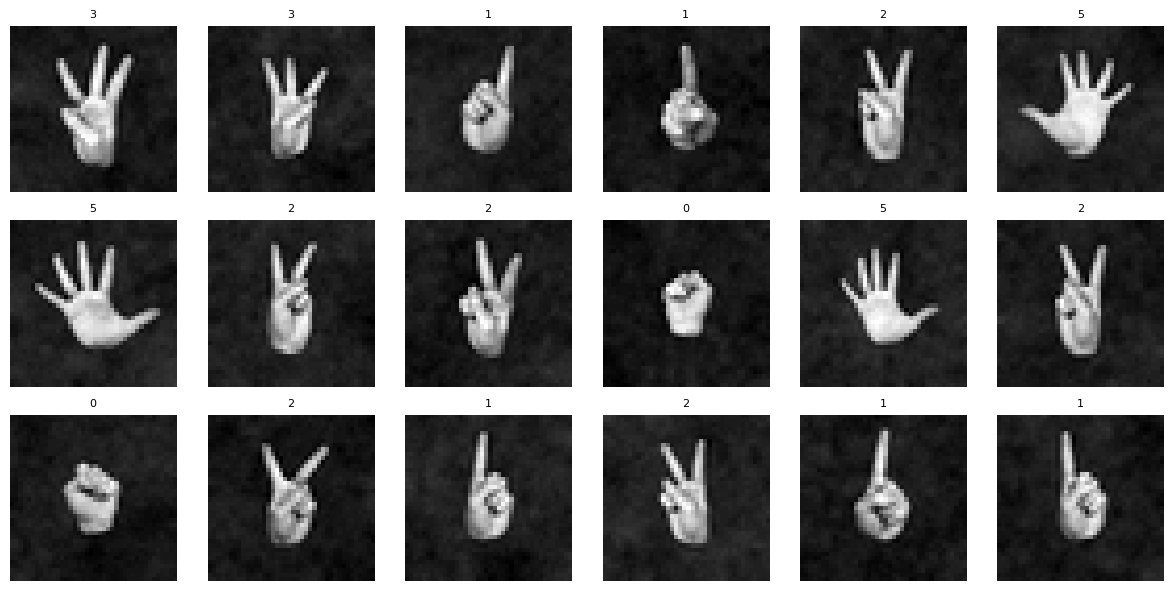

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def mostrar_grilla_imagenes(n_filas, n_cols, imagenes, etiquetas, class_names):
    fig, axes = plt.subplots(n_filas, n_cols, figsize=(12, 6))

    for ax, img, lbl in zip(axes.ravel(), imagenes, etiquetas):
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(class_names[int(lbl)], fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Parámetros de la grilla
(n_filas, n_cols) = (3, 6)  

# Generar índices aleatorios sin reemplazo
img_idx = np.random.choice(len(X), size=n_filas * n_cols, replace=False)
imagenes = X[img_idx]
etiquetas= y[img_idx]

mostrar_grilla_imagenes(n_filas, n_cols, imagenes, etiquetas, cls_names)

# Carga de Imagenes con dataset Tensorflow

Carga **lasy** (a demanda) de las imagenes, es decir que lasa medida que se las necesita

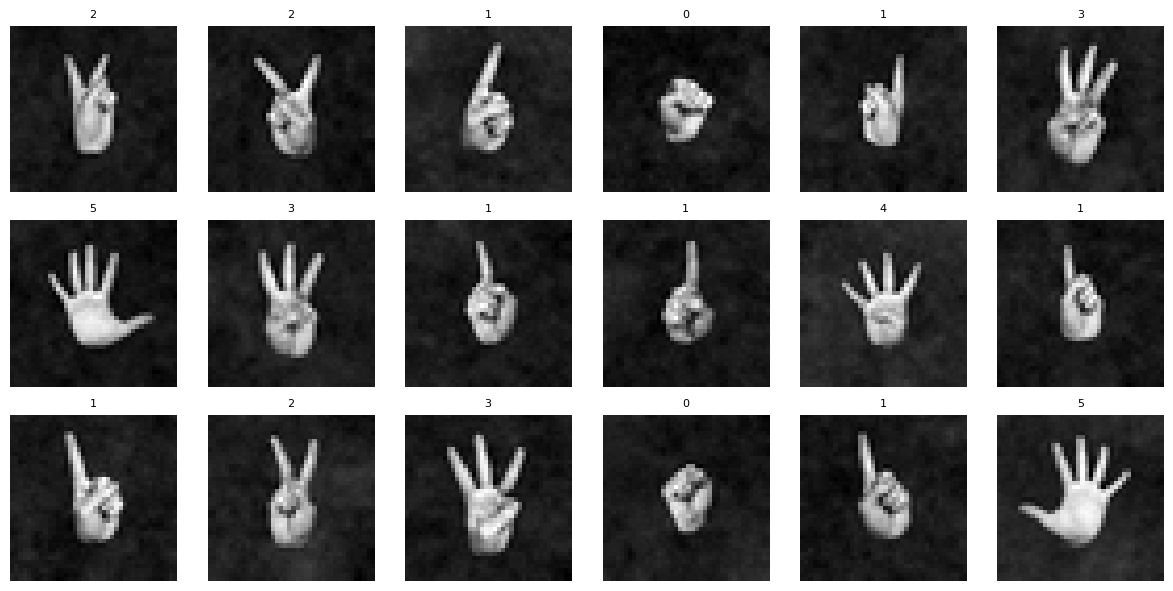

In [35]:
    import numpy as np
    import matplotlib.pyplot as plt
    import tensorflow as tf
    
    # Parámetros de la grilla
    (n_filas, n_cols) = (3, 6) 
    n_imagenes = n_filas * n_cols
    
    # Cargar imagenes como dataset tf
    ds, cls_names = DataLoader.load_images_dataset('fingers_test', resize=(40, 40), shuffle=True)

    # Extraer imágenes espaciadas
    imagenes = []
    etiquetas = []
    
    for img, lbl in ds.take(n_imagenes):
        imagenes.append(img.numpy())
        etiquetas.append(lbl.numpy())
    
    mostrar_grilla_imagenes(n_filas, n_cols, imagenes, etiquetas, cls_names)

# Data Augmentation

2026-06-11 04:38:03.947994: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


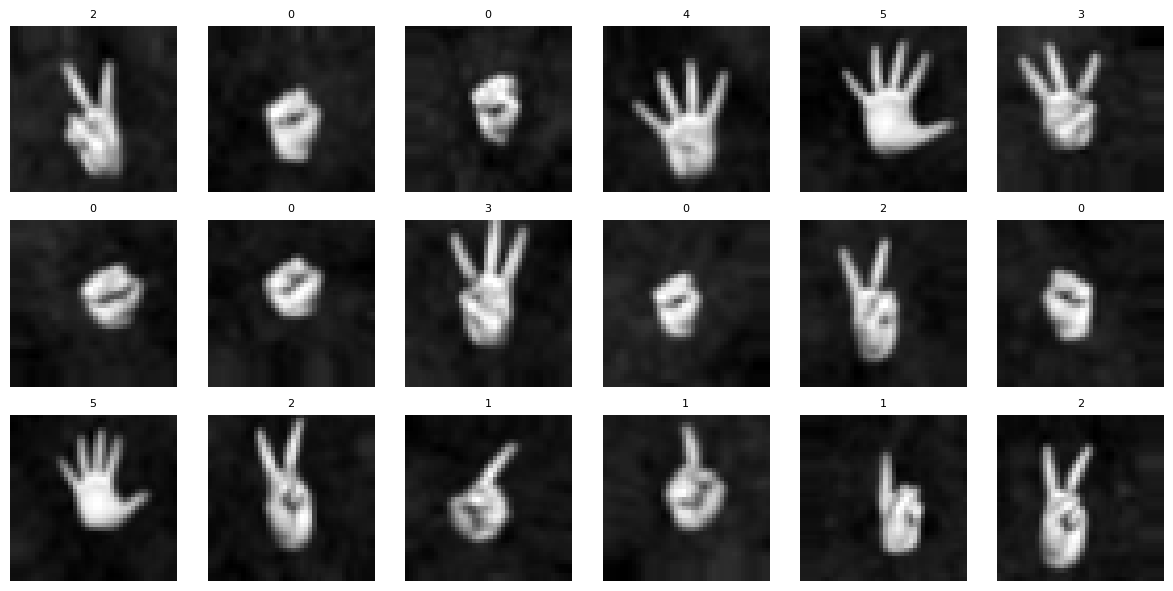

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Data augmentation
rotation = tf.keras.layers.RandomRotation(factor=0.05, fill_mode="nearest")
zoom = tf.keras.layers.RandomZoom(height_factor=(-0.10, 0.10), width_factor=(-0.10, 0.10), fill_mode="nearest")
translation = tf.keras.layers.RandomTranslation(height_factor=0.10, width_factor=0.10, fill_mode="nearest")


def augment(image, label):

    image = tf.cast(image, tf.float32) / 255.0

    if len(image.shape) == 2:
        image = tf.expand_dims(image, axis=-1)

    image = rotation(image)
    image = translation(image)
    image = zoom(image)

    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.3)

    return image, label
    
# Parámetros de la grilla
(n_filas, n_cols) = (3, 6)
n_imagenes = n_filas * n_cols

ds_raw, cls_names = DataLoader.load_images_dataset('fingers_test', resize=(40, 40), shuffle=True)

# Dataset para entrenamiento (con augmentación)
ds = ds_raw.map(augment, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

imagenes = []
etiquetas = []
for img, lbl in ds.take(n_imagenes):
    imagenes.append(img.numpy())
    etiquetas.append(lbl.numpy())

mostrar_grilla_imagenes(n_filas, n_cols, imagenes, etiquetas, cls_names)